In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from functions import *


In [6]:
data = pd.read_csv(fullDataPath('BTC'))


In [7]:
# Convert time to datetime if it's not already
data['time'] = pd.to_datetime(data['time'], errors='coerce')
data = data.dropna(subset=['time'])

# Extract date component
data['date'] = data['time'].dt.date

# Group by date and aggregate values (one row per day)
# Hard coded change later
daily_data = (
    data
    .groupby('date')
    .agg(
        close=('close', 'last'),  # Take the last close price of the day
        avg_sentiment=('score', 'mean'),  # Average sentiment for the day
        tweet_count=('score', 'count'),   # Number of observations per day
        volume=('volume', 'last'),          # Total volume for the day
        BB_Lower=('BB_Lower', 'last'),  # Last value of BB lower band
        BB_Middle=('BB_Middle', 'last'),  # Last value of BB middle band
        BB_Upper=('BB_Upper', 'last'),  # Last value of BB upper band
        SMA_50=('SMA_50', 'last'),  # Last value of SMA 50
        Volume_MA_20=('Volume_MA_20', 'last'),  # Last value of Volume MA 20
        value=('value', 'last'),
        value_classification=('value_classification', 'last'),
        OBV=('OBV', 'last')
    )
    .reset_index()
)

# Convert date back to datetime format if needed
daily_data['time'] = pd.to_datetime(daily_data['date'])
daily_data = daily_data.drop('date', axis=1)

# Sort by time
daily_data = daily_data.sort_values('time')
daily_data.set_index('time', inplace=True)
daily_data['gradient'] = daily_data['close'].diff().fillna(0.0)
daily_data

,close,avg_sentiment,tweet_count,volume,BB_Lower,BB_Middle,BB_Upper,SMA_50,Volume_MA_20,value,value_classification,OBV,gradient
time,,,,,,,,,,,,,
2024-07-12,57909.03,0.000000,1,10516.604001,59399.753225,65209.3695,71018.985775,62050.1696,9777.576091,40.0,Neutral,-312056.665872,0.00
2024-07-13,59224.58,0.000000,1,4255.105457,60892.200610,65578.3270,70264.453390,62071.3564,10033.581994,41.0,Neutral,-301540.061870,1315.55
2024-07-14,60808.42,0.000000,1,6132.374031,61558.362035,65688.0010,69817.639965,62032.8448,10590.327203,45.0,Neutral,-297284.956413,1583.84
2024-07-15,64757.16,0.000000,1,20601.733880,61518.185238,65681.3265,69844.467762,61999.4730,10684.678227,48.0,Neutral,-291152.582382,3948.74
2024-07-16,65088.99,0.000000,1,14691.920023,59993.572597,65350.0160,70706.459403,61853.7066,10170.542079,57.0,Neutral,-270550.848503,331.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,108269.84,-0.001550,1,4455.083530,101288.707658,108463.3535,115637.999342,107036.2634,0.000000,52.0,Neutral,-28844.514097,-948.14
2025-07-08,108958.04,0.000000,1,3785.390742,101288.707658,108463.3535,115637.999342,107036.2634,0.000000,50.0,Neutral,-24389.430567,688.20
2025-07-09,111282.85,27.414035,7,7683.832396,101288.707658,108463.3535,115637.999342,107036.2634,0.000000,52.0,Neutral,-20604.039825,2324.81


In [9]:
test_days = 180
series = daily_data['close']
train = series.iloc[:-test_days]
test  = series.iloc[-test_days:]

order = (5, 1, 0)
seasonal_order = (0, 0, 0, 0)
model = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(disp=False)
print(model_fit.summary())

c:\Users\matte\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\matte\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  185
Model:               SARIMAX(5, 1, 0)   Log Likelihood               -1612.112
Date:                Fri, 11 Jul 2025   AIC                           3236.224
Time:                        13:29:49   BIC                           3255.348
Sample:                    07-12-2024   HQIC                          3243.979
                         - 01-12-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0465      0.083      0.561      0.575      -0.116       0.209
ar.L2          0.0611      0.073      0.838      0.402      -0.082       0.204
ar.L3         -0.1660      0.078     -2.116      0.0

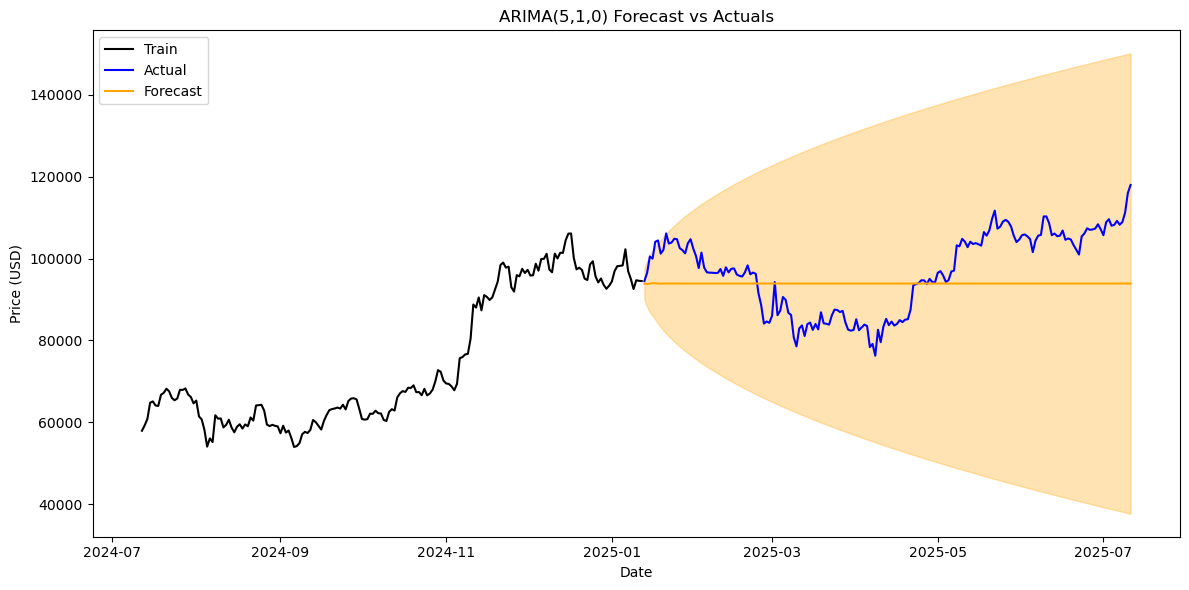

In [13]:
pred = model_fit.get_forecast(steps=test_days)
pred_mean = pred.predicted_mean
pred_ci   = pred.conf_int(alpha=0.05)

# Plot training, actual test, and forecast
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train', color='black')
plt.plot(test.index, test,   label='Actual', color='blue')
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='orange')
# Shade the 95% confidence interval
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:,0],
                 pred_ci.iloc[:,1],
                 color='orange', alpha=0.3)
plt.title('ARIMA(5,1,0) Forecast vs Actuals')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(); plt.grid(False); plt.tight_layout()
plt.show()

In [12]:
rows = []
dates = pred_mean.index
total = len(dates)
for start_idx in range(0, total - 6):
    block_dates = dates[start_idx:start_idx+7]
    start_date = block_dates[0].strftime('%Y-%m-%d')
    end_date   = block_dates[-1].strftime('%Y-%m-%d')
    block_vals = pred_mean.iloc[start_idx:start_idx+7].values
n    # Determine label by comparing last vs first forecast
    first_val = block_vals[0]
    last_val  = block_vals[-1]
    if last_val > first_val:
        label = 'Bullish'
    elif last_val < first_val:
        label = 'Bearish'
    else:
        label = 'Neutral'
    row = {'start': start_date, 'end': end_date, 'label': label}
    for i, v in enumerate(block_vals, start=1):
        row[f'day_{i}'] = v
    rows.append(row)
seq_df = pd.DataFrame(rows)
seq_df.head()


IndentationError: unexpected indent (645468358.py, line 10)

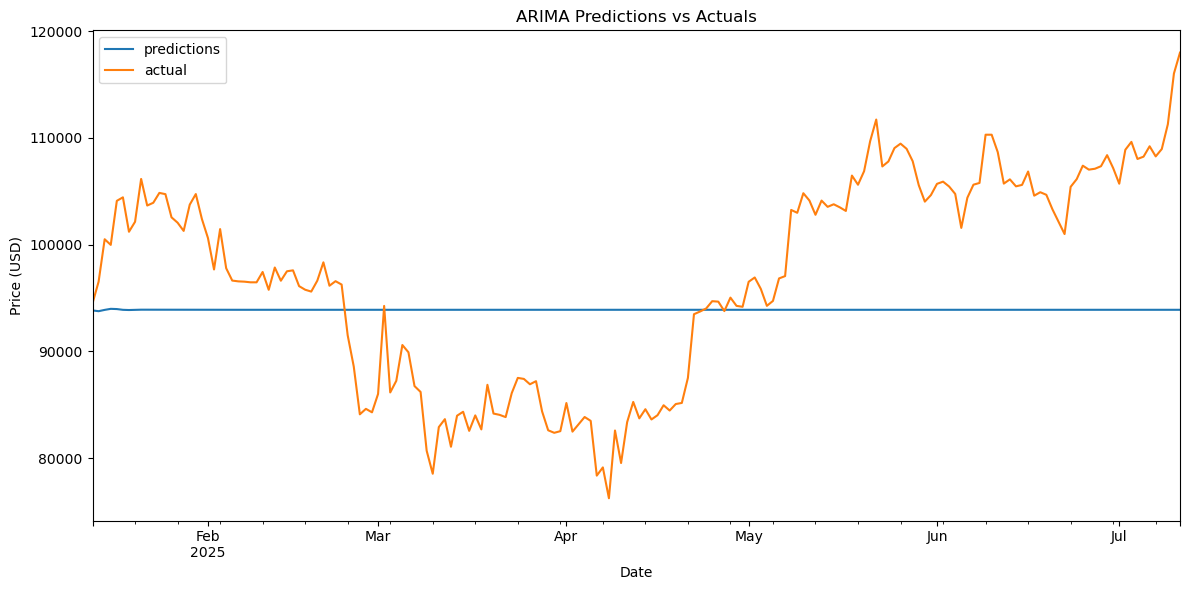

Normalized RMSE: 1.0442154600052307


In [14]:
arima_comparison = pd.DataFrame({
    'predictions': pred_mean.values,
    'actual': test.values
}, index=test.index)

# Plot predictions vs actuals
arima_comparison.plot.line(figsize=(12,6), title='ARIMA Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(False)
plt.tight_layout()
plt.show()

# Calculate RMSE normalized by test set std (like in GBM notebook)
from sklearn.metrics import mean_squared_error
rmse_normalized = (mean_squared_error(arima_comparison['predictions'], arima_comparison['actual']) ** 0.5) / test.std()
print("Normalized RMSE:", rmse_normalized)